<a href="https://colab.research.google.com/github/ravikeerthi7606/CreditCardFraudDetectionSystem/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

train_path = "/content/drive/MyDrive/ML project/fraud detection/data/train_transaction.csv"

train = pd.read_csv(train_path)

train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
print("Python libraries:")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Environment ready")

Python libraries:
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1
Environment ready


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [4]:
train.shape

(590540, 394)

In [5]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,NaN,NaN,NaN,3282269.5,170474.35832,2987000.0,3134634.75,3282269.5,3429904.25,3577539.0
isFraud,590540.0,NaN,NaN,NaN,0.03499,0.183755,0.0,0.0,0.0,0.0,1.0
TransactionDT,590540.0,NaN,NaN,NaN,7372311.310116,4617223.64654,86400.0,3027057.75,7306527.5,11246620.0,15811131.0
TransactionAmt,590540.0,NaN,NaN,NaN,135.027176,239.162522,0.251,43.321,68.769,125.0,31937.391
ProductCD,590540,5,W,439670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
V335,82351.0,NaN,NaN,NaN,59.16455,387.62948,0.0,0.0,0.0,0.0,55125.0
V336,82351.0,NaN,NaN,NaN,28.530903,274.57692,0.0,0.0,0.0,0.0,55125.0
V337,82351.0,NaN,NaN,NaN,55.352422,668.486833,0.0,0.0,0.0,0.0,104060.0
V338,82351.0,NaN,NaN,NaN,151.160542,1095.034387,0.0,0.0,0.0,0.0,104060.0


In [9]:
X = train.drop(columns=['isFraud'])
y = train['isFraud']
print(X.shape)
print(y.shape)

(590540, 393)
(590540,)


In [17]:
print(X.dtypes.value_counts())
#categorical data types
categorical_cols = X.select_dtypes(
    include = ['object']
).columns.tolist()
#numerical data types
numerical_cols = X.select_dtypes(
    include = ['number']
).columns.tolist()
print(f'categorical columns: {len(categorical_cols)}')
print(f'numerical columns: {len(numerical_cols)}')

float64    376
object      14
int64        3
Name: count, dtype: int64
categorical columns: 14
numerical columns: 379


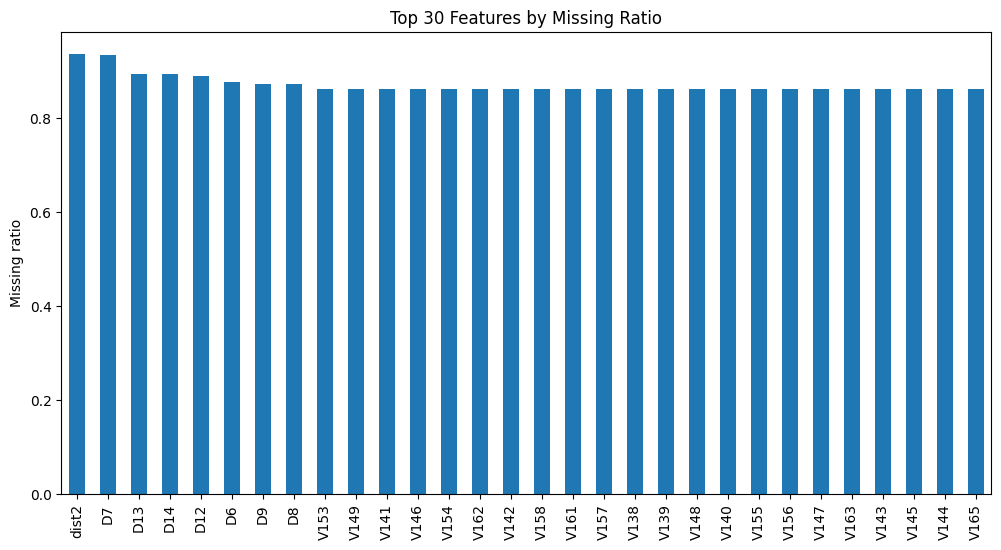

In [22]:
missing = (
    train.isnull()
    .mean()
    .sort_values(ascending=False)
)
missing.head(30)

plt.figure(figsize=(12, 6))
missing.head(30).plot(kind="bar")
plt.ylabel("Missing ratio")
plt.title("Top 30 Features by Missing Ratio")
plt.xticks(rotation=90)
plt.show()

In [23]:
missing[missing > 0.90]

,0
dist2,0.936284
D7,0.934099


isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


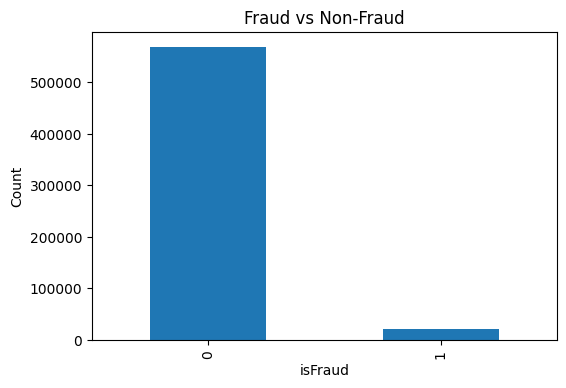

In [28]:
fraud_counts = train["isFraud"].value_counts()
print(train['isFraud'].value_counts(normalize=True)*100)
plt.figure(figsize=(6, 4))

fraud_counts.plot(kind="bar")

plt.title("Fraud vs Non-Fraud")
plt.xlabel("isFraud")
plt.ylabel("Count")

plt.show()

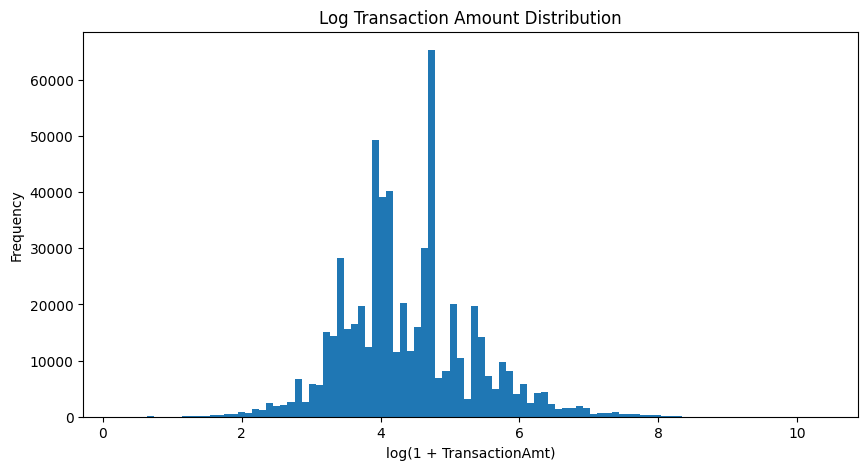

In [31]:
print(train["TransactionAmt"].describe())

plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(train["TransactionAmt"]),
    bins=100
)

plt.xlabel("log(1 + TransactionAmt)")
plt.ylabel("Frequency")
plt.title("Log Transaction Amount Distribution")

plt.show()

In [32]:
train.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64


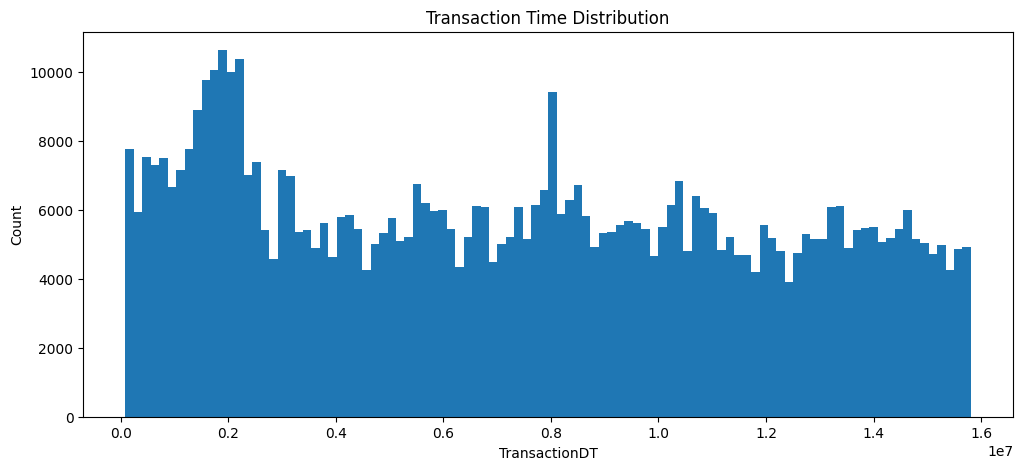

In [33]:
print(train["TransactionDT"].describe())

plt.figure(figsize=(12, 5))

plt.hist(
    train["TransactionDT"],
    bins=100
)

plt.xlabel("TransactionDT")
plt.ylabel("Count")
plt.title("Transaction Time Distribution")

plt.show()

In [36]:
#duplicates
print(f'duplicated row:{train.duplicated().sum()}')

duplicated row:0


In [37]:
#supicious leakage
train.nunique().sort_values(ascending=False).head(30)

,0
TransactionID,590540
TransactionDT,573349
V307,37367
V127,24414
V308,23064
TransactionAmt,20902
V310,19136
V306,16210
V317,15184
V203,14951
